In [ ]:
import pandas as pd          # For handling data (tables like Excel)
import numpy as np           # For numerical operations
import matplotlib.pyplot as plt   # For plotting graphs
import seaborn as sns        # For advanced visualizations

from sklearn.model_selection import train_test_split  # To split data
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Evaluation metrics

# Models
from sklearn.linear_model import LogisticRegression   # Logistic Regression model
from sklearn.tree import DecisionTreeClassifier       # Decision Tree model
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Ensemble models

In [ ]:
df = pd.read_csv("diabetes.csv")   # Load dataset from CSV file
df.head()                          # Show first 5 rows

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()      # Shows column names, data types, missing values
df.describe()  # Shows statistics like mean, min, max

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


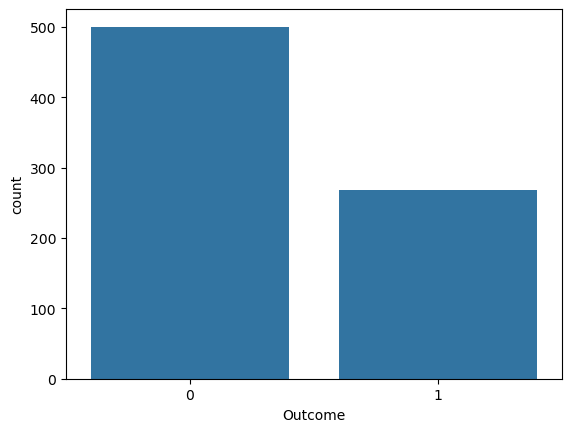

In [ ]:
sns.countplot(x='Outcome', data=df)  # Count of 0 and 1 (No diabetes / Diabetes)
plt.show()                           # Display the plot

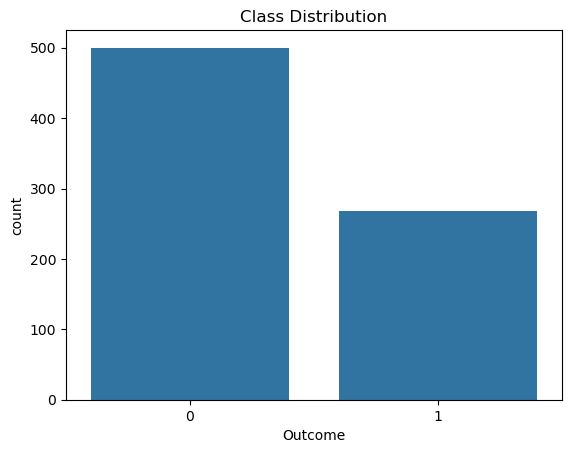

In [ ]:
# Helps understand class balance
sns.countplot(x='Outcome', data=df)   # Plot again
plt.title("Class Distribution")       # Add title
plt.show()

In [ ]:
X = df.drop('Outcome', axis=1)   # Features (input data)
y = df['Outcome']                # Target (output)

# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# Create Logistic Regression model
# max_iter increased to ensure convergence
lr = LogisticRegression(max_iter=1000)

# Train model using training data
lr.fit(X_train, y_train)

# Make predictions on test data
y_pred_lr = lr.predict(X_test)

# Evaluate model using accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7467532467532467


In [10]:
# Create Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# Train the model
dt.fit(X_train, y_train)

# Predict on test data
y_pred_dt = dt.predict(X_test)

# Evaluate performance
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7467532467532467


In [11]:
# Create Random Forest model
# n_estimators = number of trees
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf.predict(X_test)

# Evaluate performance
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7207792207792207


In [12]:
# Create Gradient Boosting model
# learning_rate controls how much each model learns
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1)

# Train the model
gb.fit(X_train, y_train)

# Predict on test data
y_pred_gb = gb.predict(X_test)

# Evaluate performance
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.7467532467532467


In [13]:
# Create a DataFrame to compare all model accuracies
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ]
})

# Sort results by highest accuracy
results = results.sort_values(by='Accuracy', ascending=False)

# Display results
print(results)

                 Model  Accuracy
0  Logistic Regression  0.746753
1        Decision Tree  0.746753
3    Gradient Boosting  0.746753
2        Random Forest  0.720779


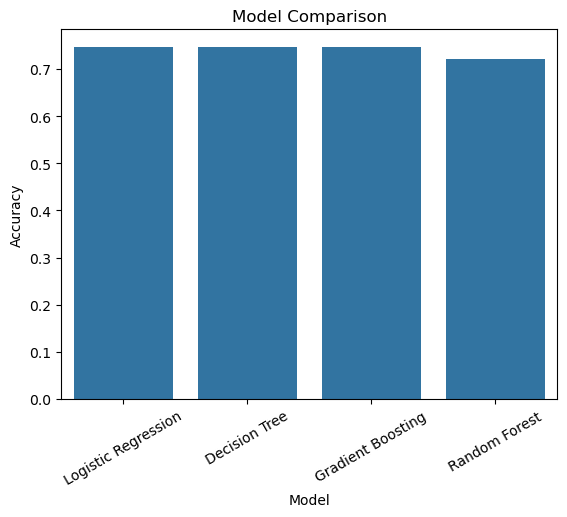

In [14]:
# Plot model comparison
sns.barplot(x='Model', y='Accuracy', data=results)

# Rotate labels for better readability
plt.xticks(rotation=30)

# Add title
plt.title("Model Comparison")

# Show plot
plt.show()

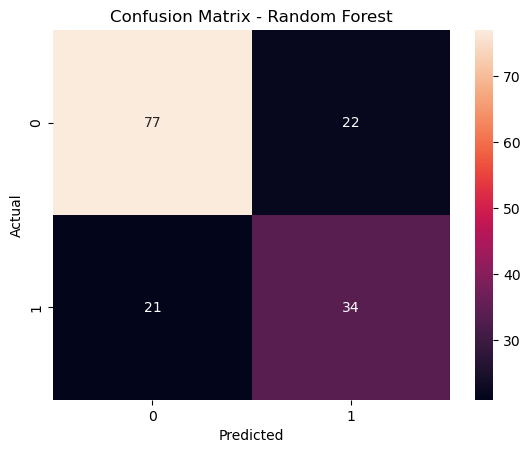

In [15]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()